# Probing Classifiers — Visual Experiments

> **Goal:** Feel the methodological pitfalls of probing — and the fixes — so introspection conclusions are trustworthy.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Complexity confound** | Can a strong probe report high accuracy even when there's nothing to read? |
| 2 | **Selectivity** | How do control tasks separate 'reading structure' from 'memorizing'? |
| 3 | **Decodable ≠ used** | Does removing a decodable property always change behaviour? |
| 4 | **MDL probing** | How do we measure how *easily* a property is extracted, not just final accuracy? |

---
**Linked theory:** [research/04-probing-classifiers-survey.md](../research/04-probing-classifiers-survey.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa', 'axes.grid': True, 'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


---
## Experiment 1: Complexity confound

**Question:** A high-capacity probe might *learn the task itself* rather than read it from the representation. Can a strong probe report high (training) accuracy when the representation holds *no* signal?

We probe **random** representations with **random** labels — there is nothing to read. A faithful probe should stay at chance.

In [2]:
np.random.seed(1)
n, dim = 600, 40
X = np.random.randn(n, dim)               # random representations
y_rand = np.random.randint(0, 2, n)       # random labels: no real signal
tr = slice(0, 400); te = slice(400, n)

lin = LogisticRegression(max_iter=1000).fit(X[tr], y_rand[tr])
mlp = MLPClassifier(hidden_layer_sizes=(256, 256), max_iter=2000, alpha=1e-5).fit(X[tr], y_rand[tr])
res = {
    'linear': (lin.score(X[tr], y_rand[tr]), lin.score(X[te], y_rand[te])),
    'MLP': (mlp.score(X[tr], y_rand[tr]), mlp.score(X[te], y_rand[te])),
}
for k, (a, b) in res.items():
    print(f'{k:7s} train acc {a:.2f}  test acc {b:.2f}')

linear  train acc 0.61  test acc 0.51
MLP     train acc 1.00  test acc 0.49


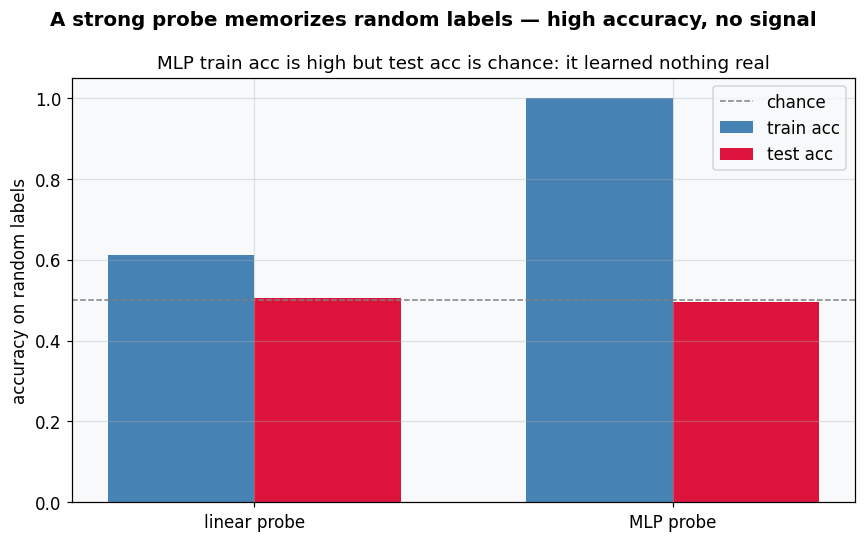

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('A strong probe memorizes random labels — high accuracy, no signal', fontsize=13, fontweight='bold')

x = np.arange(2); w = 0.35
ax.bar(x - w/2, [res['linear'][0], res['MLP'][0]], w, color='steelblue', label='train acc')
ax.bar(x + w/2, [res['linear'][1], res['MLP'][1]], w, color='crimson', label='test acc')
ax.axhline(0.5, color='gray', ls='--', lw=1, label='chance')
ax.set_xticks(x); ax.set_xticklabels(['linear probe', 'MLP probe'])
ax.set_ylabel('accuracy on random labels'); ax.set_ylim(0, 1.05)
ax.set_title('MLP train acc is high but test acc is chance: it learned nothing real')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** On random data with random labels, the MLP probe achieves high *training* accuracy but its *test* accuracy is at chance, while the linear probe is at chance on both.
2. **Why it looks this way:** A high-capacity probe can memorize arbitrary label assignments of the training set even when the representation contains no information — its training accuracy says nothing about the representation.
3. **Key takeaway:** Probe accuracy (especially a strong probe's) can be a confound; you must control for probe capacity and report held-out performance.

---
## Experiment 2: Selectivity

**Question:** Hewitt & Liang's fix: compare a probe's accuracy on the real task to its accuracy on a *control task* with random labels. Selectivity = real − control. Which probe is trustworthy?

We use a representation that linearly encodes a real property, build a control task (random labels per input), and compute selectivity for a linear and an MLP probe.

In [4]:
np.random.seed(2)
n, dim = 800, 30
X = np.random.randn(n, dim)
w_true = np.random.randn(dim)
y_real = (X @ w_true > 0).astype(int)          # real, linearly-encoded property
y_ctrl = np.random.randint(0, 2, n)            # control task: random labels
tr = slice(0, 500); te = slice(500, n)


def fit_acc(model_fn, y):
    m = model_fn().fit(X[tr], y[tr])
    return m.score(X[te], y[te])


lin_fn = lambda: LogisticRegression(max_iter=1000)
mlp_fn = lambda: MLPClassifier(hidden_layer_sizes=(256, 256), max_iter=2000, alpha=1e-5)
# control 'memorization' measured on the training set (capacity to fit random labels)
lin_ctrl_mem = lin_fn().fit(X[tr], y_ctrl[tr]).score(X[tr], y_ctrl[tr])
mlp_ctrl_mem = mlp_fn().fit(X[tr], y_ctrl[tr]).score(X[tr], y_ctrl[tr])
lin_real = fit_acc(lin_fn, y_real); mlp_real = fit_acc(mlp_fn, y_real)
lin_sel = lin_real - lin_ctrl_mem; mlp_sel = mlp_real - mlp_ctrl_mem
print(f'linear : real {lin_real:.2f}  control-fit {lin_ctrl_mem:.2f}  selectivity {lin_sel:+.2f}')
print(f'MLP    : real {mlp_real:.2f}  control-fit {mlp_ctrl_mem:.2f}  selectivity {mlp_sel:+.2f}')

linear : real 0.96  control-fit 0.59  selectivity +0.38
MLP    : real 0.95  control-fit 1.00  selectivity -0.05


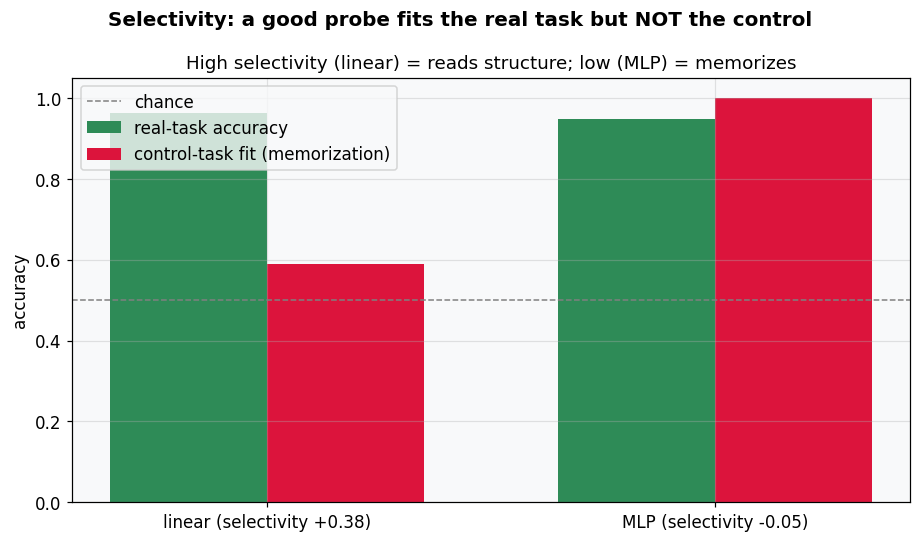

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 5))
fig.suptitle('Selectivity: a good probe fits the real task but NOT the control', fontsize=13, fontweight='bold')

x = np.arange(2); w = 0.35
ax.bar(x - w/2, [lin_real, mlp_real], w, color='seagreen', label='real-task accuracy')
ax.bar(x + w/2, [lin_ctrl_mem, mlp_ctrl_mem], w, color='crimson', label='control-task fit (memorization)')
ax.axhline(0.5, color='gray', ls='--', lw=1, label='chance')
ax.set_xticks(x); ax.set_xticklabels([f'linear (selectivity {lin_sel:+.2f})', f'MLP (selectivity {mlp_sel:+.2f})'])
ax.set_ylabel('accuracy'); ax.set_ylim(0, 1.05)
ax.set_title('High selectivity (linear) = reads structure; low (MLP) = memorizes')
ax.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The linear probe solves the real task while barely fitting the control task — high selectivity. The MLP probe also solves the real task but fits the control task too — low selectivity.
2. **Why it looks this way:** Selectivity penalizes a probe that can memorize arbitrary labels. The linear probe lacks the capacity to fit random control labels, so its real-task success is meaningful; the MLP's is ambiguous.
3. **Key takeaway:** Report selectivity, not raw accuracy — a probe is informative only if it can fit the real task much better than a random control.

---
## Experiment 3: Decodable ≠ used

**Question:** A property can be perfectly decodable yet unused by the model. Amnesic probing removes a property and checks whether behaviour changes. Does removing a *used* vs *unused* property differ?

Two properties A and B are both linearly decodable from the representation, but the downstream task depends only on A. We amnesically remove each and re-measure task accuracy.

In [6]:
np.random.seed(3)
n = 1500
A = np.random.randn(n); B = np.random.randn(n); noise = np.random.randn(n, 10)
# representation mixes A, B, noise via a random map
raw = np.column_stack([A, B, noise])
M = np.random.randn(12, 30); R = raw @ M
task = (A > 0).astype(int)               # the downstream task depends ONLY on A
lab_A = (A > 0).astype(int); lab_B = (B > 0).astype(int)
tr = slice(0, 1000); te = slice(1000, n)


def probe_acc(X, y):
    return LogisticRegression(max_iter=1000).fit(X[tr], y[tr]).score(X[te], y[te])


def remove_dir(X, y):
    # amnesic: project out the linear direction that predicts y (one INLP step)
    w = LogisticRegression(max_iter=1000).fit(X, y).coef_[0]
    w = w / np.linalg.norm(w)
    return X - np.outer(X @ w, w)


dec_A, dec_B = probe_acc(R, lab_A), probe_acc(R, lab_B)
task_full = probe_acc(R, task)
task_no_A = probe_acc(remove_dir(R, lab_A), task)
task_no_B = probe_acc(remove_dir(R, lab_B), task)
print(f'decodable?  A: {dec_A:.2f}  B: {dec_B:.2f}   (both high -> both decodable)')
print(f'task acc    full {task_full:.2f}  amnesic-A {task_no_A:.2f}  amnesic-B {task_no_B:.2f}')

decodable?  A: 0.99  B: 0.99   (both high -> both decodable)
task acc    full 0.99  amnesic-A 0.63  amnesic-B 0.98


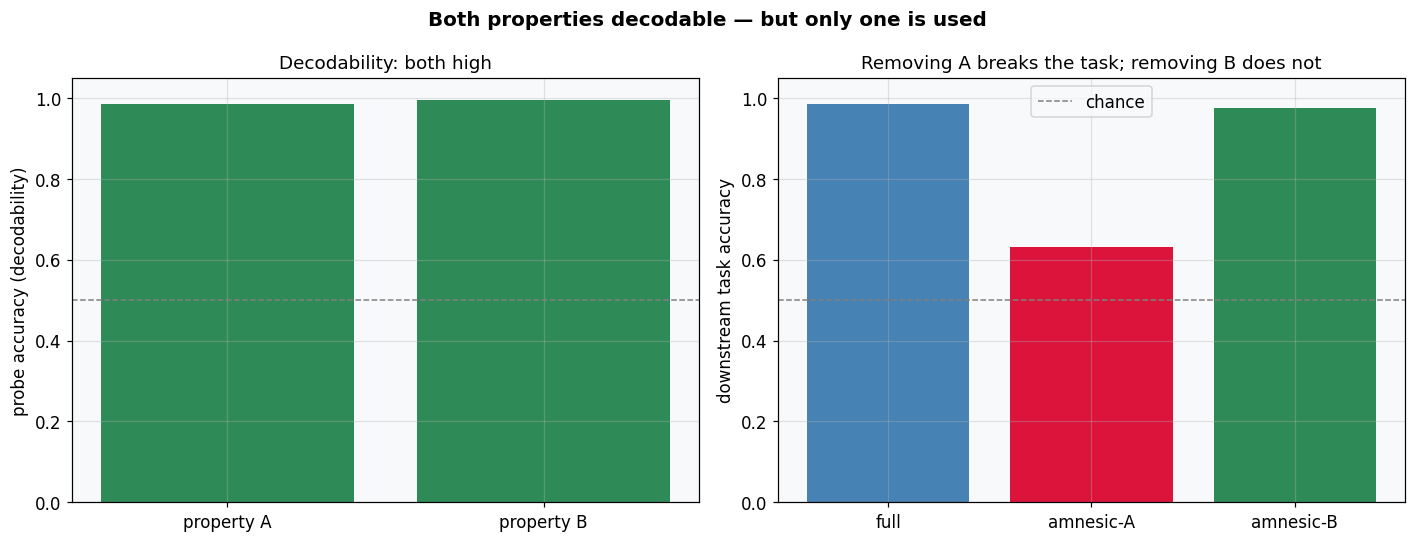

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Both properties decodable — but only one is used', fontsize=13, fontweight='bold')

axes[0].bar(['property A', 'property B'], [dec_A, dec_B], color='seagreen')
axes[0].axhline(0.5, color='gray', ls='--', lw=1)
axes[0].set_ylabel('probe accuracy (decodability)'); axes[0].set_ylim(0, 1.05)
axes[0].set_title('Decodability: both high')

axes[1].bar(['full', 'amnesic-A', 'amnesic-B'], [task_full, task_no_A, task_no_B],
            color=['steelblue', 'crimson', 'seagreen'])
axes[1].axhline(0.5, color='gray', ls='--', lw=1, label='chance')
axes[1].set_ylabel('downstream task accuracy'); axes[1].set_ylim(0, 1.05)
axes[1].set_title('Removing A breaks the task; removing B does not')
axes[1].legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** Both A and B are highly decodable (left). But amnesically removing A collapses the downstream task to chance, while removing B leaves it intact (right).
2. **Why it looks this way:** Decodability only means the information is present. The task here is defined by A, so erasing A's direction destroys the needed signal; B is decodable but irrelevant, so erasing it changes nothing.
3. **Key takeaway:** 'Decodable' is not 'used' — establishing that the model *relies* on a property needs a causal intervention like amnesic probing, not a probe accuracy number.

---
## Experiment 4: MDL probing

**Question:** Two properties may both reach high final accuracy, but one is encoded far more accessibly. Minimum description length probing measures how *easily* a property is extracted via the learning curve.

We compare an easily-encoded property (aligned with the representation) against an entangled one, plotting accuracy as the probe sees more data.

In [8]:
np.random.seed(4)
n, dim = 2000, 20
X = np.random.randn(n, dim)
easy = (X[:, 0] > 0).astype(int)                          # cleanly aligned with one axis
hard = (X @ np.random.randn(dim) + 0.8 * np.random.randn(n) > 0).astype(int)  # entangled + noisy
te = slice(1500, n)
sizes = [10, 20, 40, 80, 160, 320, 640, 1200]


def curve(y):
    accs = []
    for k in sizes:
        clf = LogisticRegression(max_iter=1000).fit(X[:k], y[:k])
        accs.append(clf.score(X[te], y[te]))
    return np.array(accs)


acc_easy, acc_hard = curve(easy), curve(hard)
# MDL proxy: smaller area ABOVE the curve = shorter description length (easier to extract)
mdl_easy = (1 - acc_easy).sum(); mdl_hard = (1 - acc_hard).sum()
print(f'MDL proxy (lower = easier)  easy: {mdl_easy:.2f}   hard: {mdl_hard:.2f}')

MDL proxy (lower = easier)  easy: 0.83   hard: 1.46


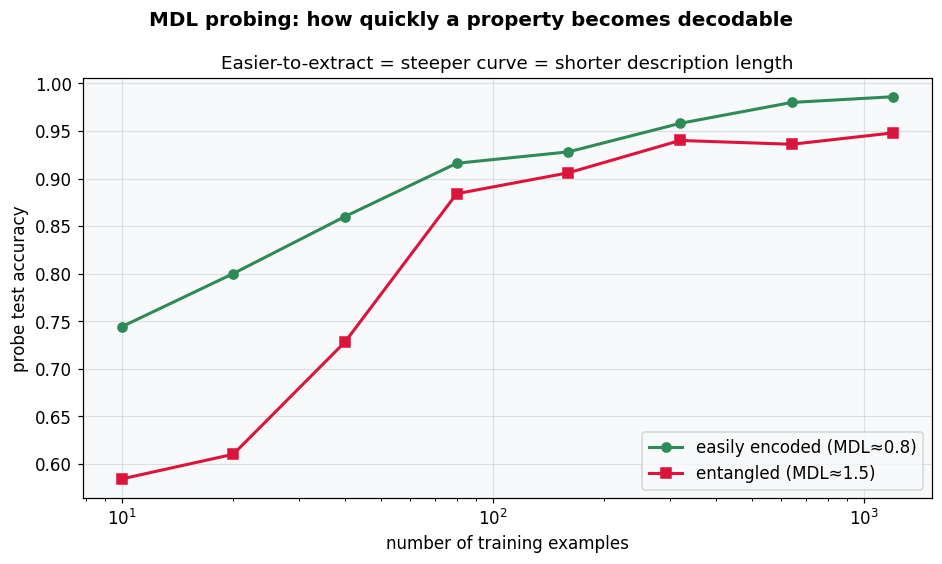

In [9]:
fig, ax = plt.subplots(figsize=(8.7, 5.2))
fig.suptitle('MDL probing: how quickly a property becomes decodable', fontsize=13, fontweight='bold')

ax.plot(sizes, acc_easy, '-o', color='seagreen', lw=2, label=f'easily encoded (MDL≈{mdl_easy:.1f})')
ax.plot(sizes, acc_hard, '-s', color='crimson', lw=2, label=f'entangled (MDL≈{mdl_hard:.1f})')
ax.set_xscale('log')
ax.set_xlabel('number of training examples'); ax.set_ylabel('probe test accuracy')
ax.set_title('Easier-to-extract = steeper curve = shorter description length')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The easily-encoded property (green) reaches high accuracy with very few examples; the entangled one (red) needs far more data to climb. Both may end high, but their learning curves — and MDL — differ.
2. **Why it looks this way:** When a property aligns cleanly with the representation, a probe extracts it from little data (short description length). An entangled, noisy property requires more evidence, signalling weaker/less accessible encoding.
3. **Key takeaway:** MDL probing captures *how accessibly* a property is encoded, a more robust signal than final accuracy and less sensitive to the probe-complexity confound.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Complexity confound | A strong probe can memorize random labels — high accuracy without any real signal. |
| 2. Selectivity | Control tasks reveal whether a probe reads structure or memorizes; report selectivity. |
| 3. Decodable ≠ used | A property can be decodable yet unused; amnesic removal tests causal usage. |
| 4. MDL probing | Learning curves measure how *accessibly* a property is encoded, robust to probe capacity. |

### Connection to the broader theory

This survey is the methodology manual for Layer A: it says when to trust a [probe](../../05-probing-intervention/research/01-linear-probing.md), when to add control tasks, and when only a [causal intervention](../../05-probing-intervention/research/04-causal-intervention-vs-observational.md) settles the question of *use*. With supervised probing mapped, the tier ends with the unsupervised tools for *seeing* high-dimensional latents — **UMAP** and **PaCMAP**.